## XGBoost v3
- Improves from v2 by using stratified k fold and sample weights

In [24]:
from dotenv import load_dotenv
import kagglehub
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report
import torch
from xgboost import XGBClassifier
from scipy.optimize import differential_evolution

if torch.cuda.is_available():
    device="cuda"
else:
    device="cpu"
device

'cuda'

In [15]:
load_dotenv()

if not Path("../Data/.complete/competitions/playground-series-s6e6/bundle.complete").is_file():
    kagglehub.competition_download("playground-series-s6e6", output_dir="Data")
    print("Data downloaded")
else:
    print("Data not downloaded, already exists")

Data not downloaded, already exists


In [16]:
train = pd.read_csv("../Data/train.csv", index_col="id")
train.head()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
id,,,,,,,,,,,
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [17]:
def add_features(df):
    df = df.copy()

    bands = ['u', 'g', 'r', 'i', 'z']

    # mag stats
    df['mag_mean'] = df[bands].mean(axis=1)
    df['mag_std'] = df[bands].std(axis=1)
    df['mag_max'] = df[bands].max(axis=1)
    df['mag_min'] = df[bands].min(axis=1)
    df['mag_range'] = df['mag_max'] - df['mag_min']

    # color indices
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    df['u_r'] = df['u'] - df['r']
    df['u_i'] = df['u'] - df['i']
    df['u_z'] = df['u'] - df['z']
    df['g_i'] = df['g'] - df['i']
    df['g_z'] = df['g'] - df['z']
    df['r_z'] = df['r'] - df['z']

    # spatial trigonometry
    alpha_rad = np.radians(df["alpha"])
    delta_rad = np.radians(df["delta"])
    df["alpha_sin"] = np.sin(alpha_rad)
    df["alpha_cos"] = np.cos(alpha_rad)
    df["delta_sin"] = np.sin(delta_rad)
    df["delta_cos"] = np.cos(delta_rad)

    # redshift interactions
    epsilon = 1e-5
    abs_redshift = df['redshift'].abs() + epsilon
    for col in ['u_g', 'g_r', 'r_i', 'i_z']:
        df[f'{col}_per_redshift'] = df[col] / abs_redshift
    for b in bands:
        df[f'redshift_{b}'] = df['redshift'] * df[b]
    
    return df

In [18]:
X = add_features(train).drop(columns=["class"])
categorical_cols = ["spectral_type", "galaxy_population"]
for col in categorical_cols:
    X[col] = X[col].astype("category")

le = LabelEncoder()
y = le.fit_transform(train["class"])

test = pd.read_csv("../Data/test.csv", index_col="id")
test = add_features(test)
for col in categorical_cols:
    test[col] = test[col].astype("category")

In [19]:
n_splits = 5
SEEDS = [42, 2024, 777]

test_probs = np.zeros((len(test), 3))
oof_probs = np.zeros((len(X), 3))

fold_histories = []

for seed in SEEDS:
    print(f'Using seed {seed}')

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=seed
    )

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y[train_idx]
        y_val = y[val_idx]
        
        sample_weights = compute_sample_weight(
            class_weight="balanced",
            y=y_train
        )

        model = XGBClassifier(
            device=device,
            random_state=seed,
            n_estimators=2000,
            learning_rate=0.05,
            max_depth=5,
            early_stopping_rounds=100,
            enable_categorical=True
        )

        print(f'Training fold {fold}')

        model.fit(
            X_train,
            y_train,
            sample_weight=sample_weights,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        fold_histories.append(model.evals_result())

        oof_probs[val_idx] += model.predict_proba(X_val) / len(SEEDS)
        test_probs += model.predict_proba(test) / (n_splits * len(SEEDS))

oof_preds = np.argmax(oof_probs, axis=1)

Using seed 42
Training fold 1
Training fold 2
Training fold 3
Training fold 4
Training fold 5
Using seed 2024
Training fold 1
Training fold 2
Training fold 3
Training fold 4
Training fold 5
Using seed 777
Training fold 1
Training fold 2
Training fold 3
Training fold 4
Training fold 5


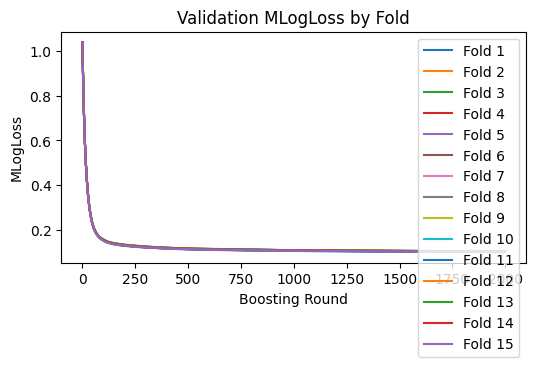

In [20]:
plt.figure(figsize=(6, 3))

for i, history in enumerate(fold_histories, 1):
    plt.plot(history["validation_0"]["mlogloss"], label=f"Fold {i}")

plt.xlabel("Boosting Round")
plt.ylabel("MLogLoss")
plt.title("Validation MLogLoss by Fold")
plt.legend()
plt.show()

In [21]:
print("OOF Accuracy:", accuracy_score(y, oof_preds))
print("OOF Balanced Accuracy:", balanced_accuracy_score(y, oof_preds))
print(classification_report(y, oof_preds, target_names=le.classes_))

OOF Accuracy: 0.9626948784699669
OOF Balanced Accuracy: 0.9656687676376022
              precision    recall  f1-score   support

      GALAXY       0.99      0.96      0.97    377480
         QSO       0.95      0.97      0.96    117143
        STAR       0.87      0.96      0.92     82724

    accuracy                           0.96    577347
   macro avg       0.94      0.97      0.95    577347
weighted avg       0.96      0.96      0.96    577347



In [30]:
def optimize_class_weights(oof_probs, y_true):
    def objective(weights):
        weighted_probs = oof_probs * weights
        preds = np.argmax(weighted_probs, axis=1)
        return -balanced_accuracy_score(y_true, preds)

    bounds = [(0.5, 2.0), (0.5, 2.0), (0.5, 2.0)]

    result = differential_evolution(
        objective,
        bounds=bounds,
        seed=42,
        polish=True
    )

    return result.x, -result.fun

best_weights, best_score = optimize_class_weights(oof_probs, y)

uncalibrated_preds = np.argmax(oof_probs, axis=1)
calibrated_preds = np.argmax(oof_probs * best_weights, axis=1)

print("Uncalibrated balanced accuracy:", balanced_accuracy_score(y, uncalibrated_preds))
print("Calibrated balanced accuracy:", balanced_accuracy_score(y, calibrated_preds))
print(classification_report(y, calibrated_preds, target_names=le.classes_))

Uncalibrated balanced accuracy: 0.9656687676376022
Calibrated balanced accuracy: 0.9659773667904411
              precision    recall  f1-score   support

      GALAXY       0.99      0.96      0.97    377480
         QSO       0.96      0.97      0.96    117143
        STAR       0.86      0.97      0.91     82724

    accuracy                           0.96    577347
   macro avg       0.94      0.97      0.95    577347
weighted avg       0.96      0.96      0.96    577347



In [31]:
test_preds = np.argmax(test_probs * best_weights, axis=1)
test_pred_labels = le.inverse_transform(test_preds)

submission = pd.DataFrame({
    "id": test.index,
    "class": test_pred_labels
})

submission.to_csv("../Data/submission_xgboost_v3.csv", index=False)

submission.head()

,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
